# Adversarial Attacks Demo with PyBox

This notebook demonstrates how to use PyBox's `AdversarialExplainer` to visualize adversarial attacks on a trained neural network. We'll train a simple CNN on CIFAR-10 images and then generate adversarial examples using various attack methods.

## Prerequisites

Make sure you have PyBox and the required dependencies installed:

```bash
pip install pybox torch torchvision adversarial-robustness-toolbox
```

This demo uses:
- PyTorch for the neural network
- Torchvision for CIFAR-10 dataset
- ART (Adversarial Robustness Toolbox) for attack implementations
- PyBox for visualization

**Note**: This notebook trains a model from scratch, which may take several minutes. You can skip the training cell if you have a pre-trained model.

## Step 1: Import Libraries

First, let's import all the necessary libraries for this demo.

In [14]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
# Import torch transforms if needed
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader 
from art.estimators.classification import PyTorchClassifier
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

# Add src to path to import the local module
sys.path.append(os.path.abspath("src"))

## Step 2: Define the Neural Network Model

We'll create a simple Convolutional Neural Network (CNN) that can classify CIFAR-10 images. This model will be our target for adversarial attacks.

In [15]:
# Define a simple CNN model
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        # Input: (3, 28, 28) after permuting from (28, 28, 3)
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 3 * 3, 10)

    def forward(self, x):
        # Permute from (N, H, W, C) to (N, C, H, W) since channels_first=False in classifier
        x = x.permute(0, 3, 1, 2)
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.reshape(x.size(0), -1)  # Changed from view to reshape to handle non-contiguous tensors
        x = self.fc(x)
        return x

model = SimpleModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## Step 3: Train the Model

We'll train our CNN on CIFAR-10 images resized to 28x28 pixels. This is a simplified version for demo purposes - in practice, you'd want to train longer and use the full resolution.

**Note**: This training may take 5-10 minutes depending on your hardware. You can reduce the number of epochs if needed.

In [16]:
# Simple 1-epoch training on MNIST
# Prepare transforms and training dataset and loader
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop: 1 epoch
model.train()
for epoch in range(5):
    running_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        # inputs: (N, 3, 28, 28) -> convert to (N, 28, 28, 3)
        inputs = inputs.permute(0, 2, 3, 1).to(device)  # (N, 28, 28, 3)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 200 == 199:  # print every 200 mini-batches
            print(f"[Epoch {epoch + 1}, Batch {batch_idx + 1}] loss: {running_loss / 200:.3f}")
            running_loss = 0.0

print("Finished training for 1 epoch")

[Epoch 1, Batch 200] loss: 2.002
[Epoch 1, Batch 400] loss: 1.694
[Epoch 1, Batch 400] loss: 1.694
[Epoch 1, Batch 600] loss: 1.607
[Epoch 1, Batch 600] loss: 1.607
[Epoch 2, Batch 200] loss: 1.510
[Epoch 2, Batch 200] loss: 1.510
[Epoch 2, Batch 400] loss: 1.524
[Epoch 2, Batch 400] loss: 1.524
[Epoch 2, Batch 600] loss: 1.462
[Epoch 2, Batch 600] loss: 1.462
[Epoch 3, Batch 200] loss: 1.442
[Epoch 3, Batch 200] loss: 1.442
[Epoch 3, Batch 400] loss: 1.441
[Epoch 3, Batch 400] loss: 1.441
[Epoch 3, Batch 600] loss: 1.421
[Epoch 3, Batch 600] loss: 1.421
[Epoch 4, Batch 200] loss: 1.396
[Epoch 4, Batch 200] loss: 1.396
[Epoch 4, Batch 400] loss: 1.403
[Epoch 4, Batch 400] loss: 1.403
[Epoch 4, Batch 600] loss: 1.401
[Epoch 4, Batch 600] loss: 1.401
[Epoch 5, Batch 200] loss: 1.383
[Epoch 5, Batch 200] loss: 1.383
[Epoch 5, Batch 400] loss: 1.385
[Epoch 5, Batch 400] loss: 1.385
[Epoch 5, Batch 600] loss: 1.354
[Epoch 5, Batch 600] loss: 1.354
Finished training for 1 epoch
Finished trai

## Step 4: Wrap Model with ART

To use adversarial attack methods from the Adversarial Robustness Toolbox (ART), we need to wrap our PyTorch model in an ART classifier.

In [17]:
# Wrap the model in ART's PyTorchClassifier
# We use channels_first=False because we will provide input as (N, H, W, C) for plotting compatibility
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(28, 28, 3),
    nb_classes=10,
    channels_first=False 
)

In [18]:
# Import PyBox's AdversarialExplainer
from pybox.visualization import AdversarialExplainer

# Load CIFAR-10 test data
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])

testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=3, shuffle=True)

# Get a small batch of images and labels
images, labels = next(iter(testloader))  # images: (N, 3, 28, 28)

# Convert to numpy and reshape to (N, H, W, C) for PyBox
input_imgs = images.permute(0, 2, 3, 1).numpy().astype(np.float32)  # (N, 28, 28, 3)

print('Loaded CIFAR-10 batch with shapes:', input_imgs.shape, labels.numpy())

Loaded CIFAR-10 batch with shapes: (3, 28, 28, 3) [3 7 9]


## Step 6: Generate Adversarial Examples

Now comes the exciting part! We'll use PyBox's `AdversarialExplainer` to generate and visualize adversarial examples.

The available attack methods are:
- `'cwL2'`: Carlini & Wagner L2 attack (powerful but slow)
- `'deepfool'`: DeepFool attack (efficient for small perturbations)
- `'fgsm'`: Fast Gradient Sign Method (fast but less effective)
- `'pgd'`: Projected Gradient Descent (iterative, good balance)

We'll demonstrate different difference calculation methods to highlight how adversarial perturbations affect the images.

In [25]:
# Define attack methods to use
methods = ["cwL2", "deepfool"]

# Color map for difference visualization
cmap = "GRAY"  # Use "RGB" for color differences

print(f"Using attack methods: {methods}")
print(f"Using color map: {cmap}")

Using attack methods: ['cwL2', 'deepfool']
Using color map: GRAY


### Mean Absolute Error (MAE) Differences

MAE calculates the absolute differences between pixels. This highlights where the adversarial perturbations are largest.

Generating adversarial images: 100%|██████████| 3/3 [00:04<00:00,  1.54s/it]



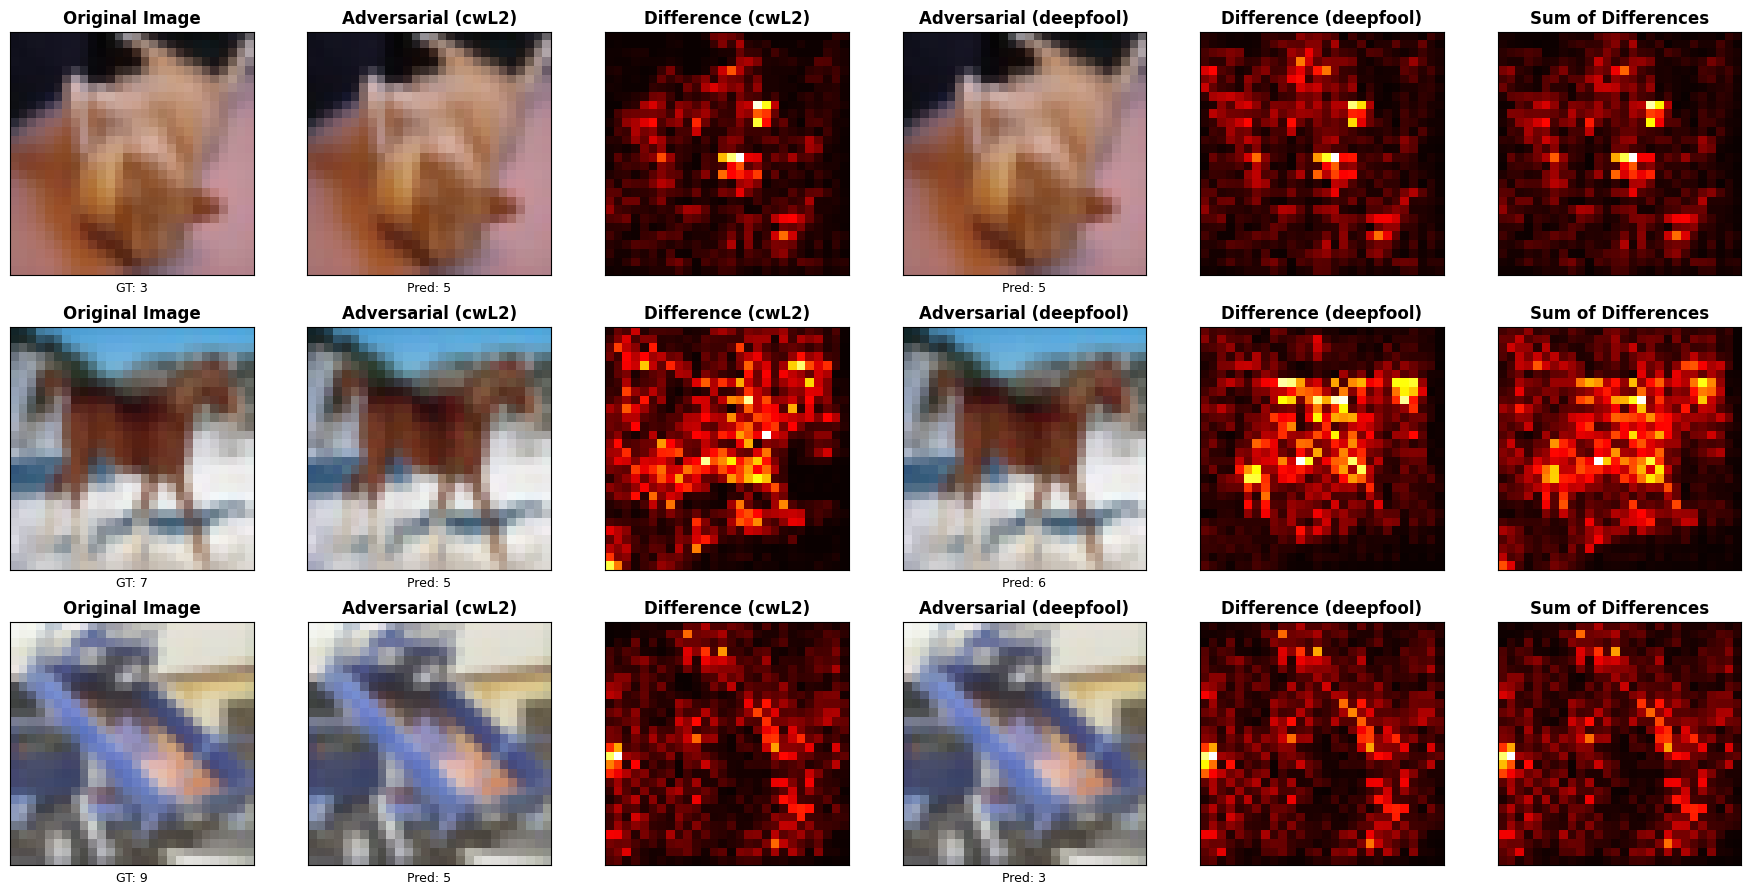

In [26]:
# Create explainer with MAE differences
explainer_mae = AdversarialExplainer(
    classifier, 
    methods, 
    difference_calculation='MAE', 
    cmap=cmap
)

# Generate and visualize adversarial examples
explainer_mae.explain(input_imgs, labels.numpy(), predict_labels=True)

### Mean Squared Error (MSE) Differences

MSE squares the differences, so it emphasizes larger perturbations more strongly than MAE.

Generating adversarial images: 100%|██████████| 3/3 [00:04<00:00,  1.44s/it]



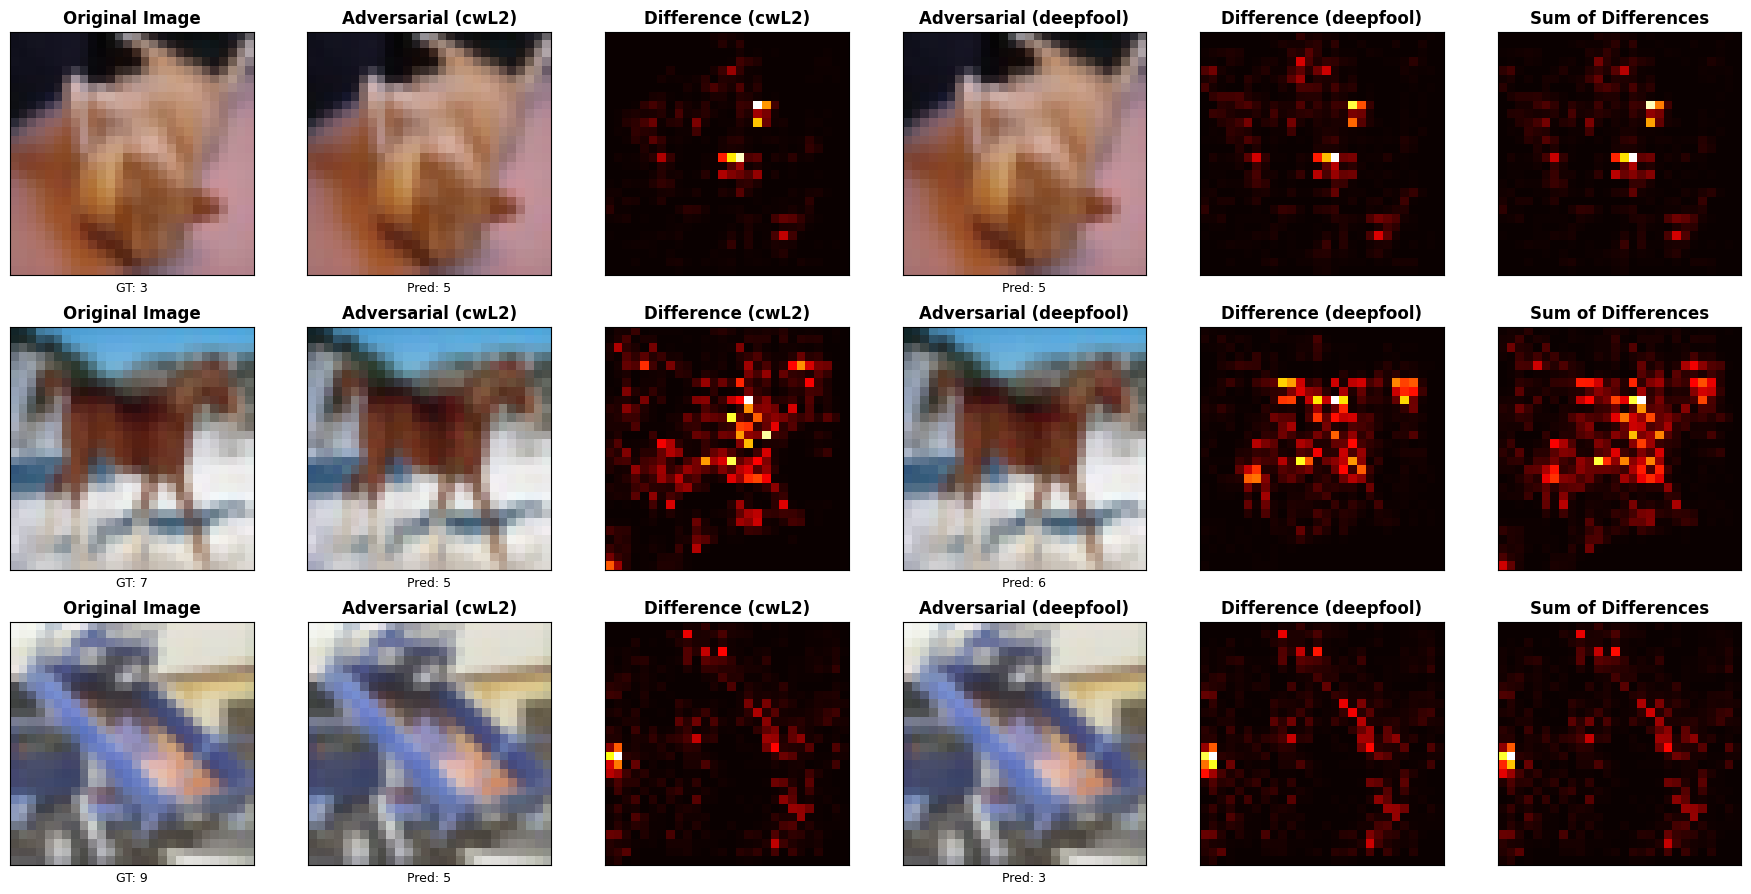

In [27]:
# Create explainer with MSE differences
explainer_mse = AdversarialExplainer(
    classifier, 
    methods, 
    difference_calculation='MSE', 
    cmap=cmap
)

# Generate and visualize adversarial examples
explainer_mse.explain(input_imgs, labels.numpy(), predict_labels=True)

### Root Mean Square Error (RMSE) Differences

RMSE is the square root of MSE, providing a normalized measure of pixel differences that can be easier to interpret.

Generating adversarial images: 100%|██████████| 3/3 [00:04<00:00,  1.40s/it]



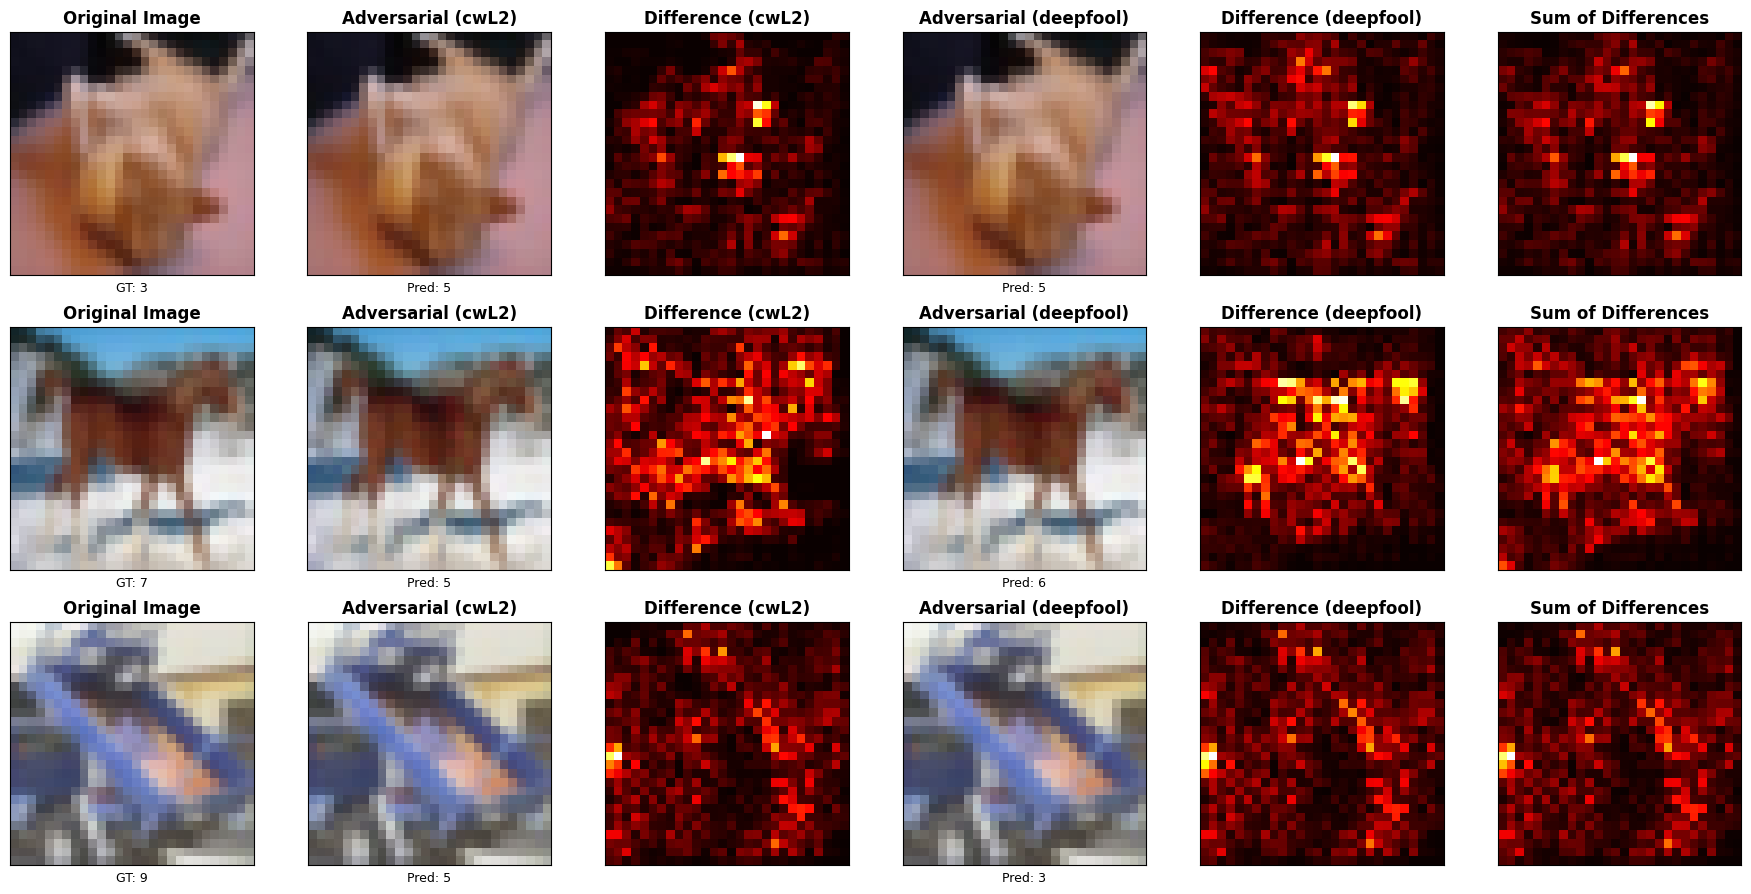

In [28]:
# Create explainer with RMSE differences
explainer_rmse = AdversarialExplainer(
    classifier, 
    methods, 
    difference_calculation='RMSE', 
    cmap=cmap
)

# Generate and visualize adversarial examples
explainer_rmse.explain(input_imgs, labels.numpy(), predict_labels=True)

### Cosine Distance Differences

Cosine distance measures the angular difference between pixel vectors, useful for understanding directional changes in the image space.

Generating adversarial images: 100%|██████████| 3/3 [00:04<00:00,  1.44s/it]



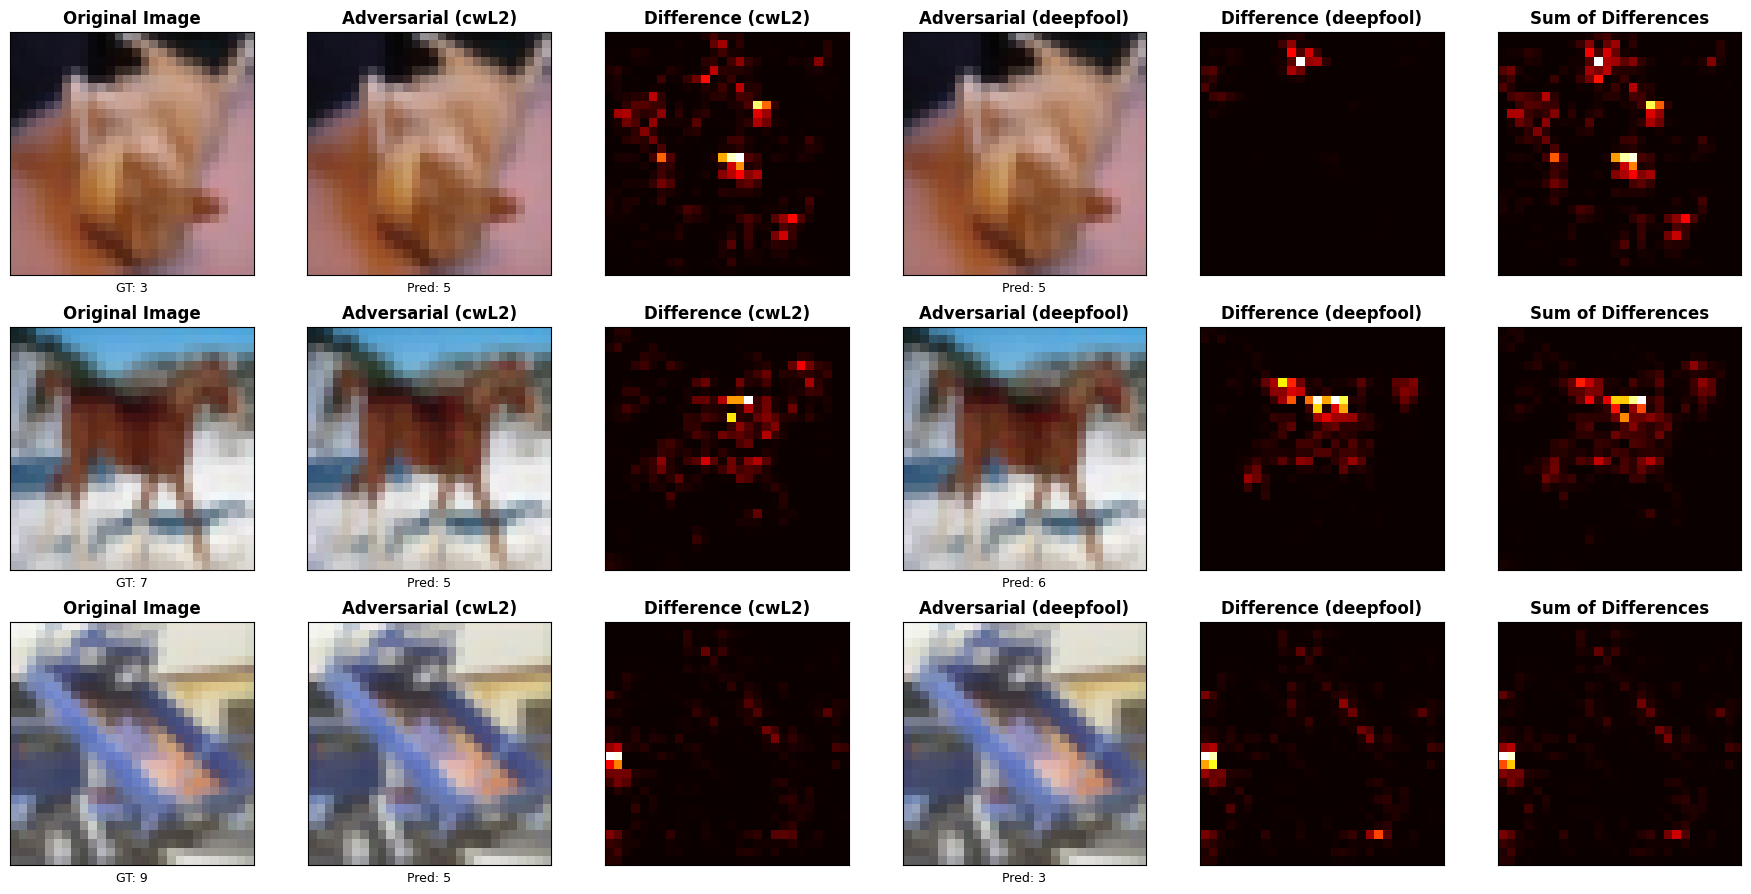

In [29]:
# Create explainer with COSINE differences
explainer_cosine = AdversarialExplainer(
    classifier, 
    methods, 
    difference_calculation='COSINE', 
    cmap=cmap
)

# Generate and visualize adversarial examples
explainer_cosine.explain(input_imgs, labels.numpy(), predict_labels=True)

### Gradient Magnitude Difference (GMD)

GMD compares the gradients/edges in the images, highlighting structural changes caused by adversarial attacks.

Generating adversarial images: 100%|██████████| 3/3 [00:03<00:00,  1.33s/it]



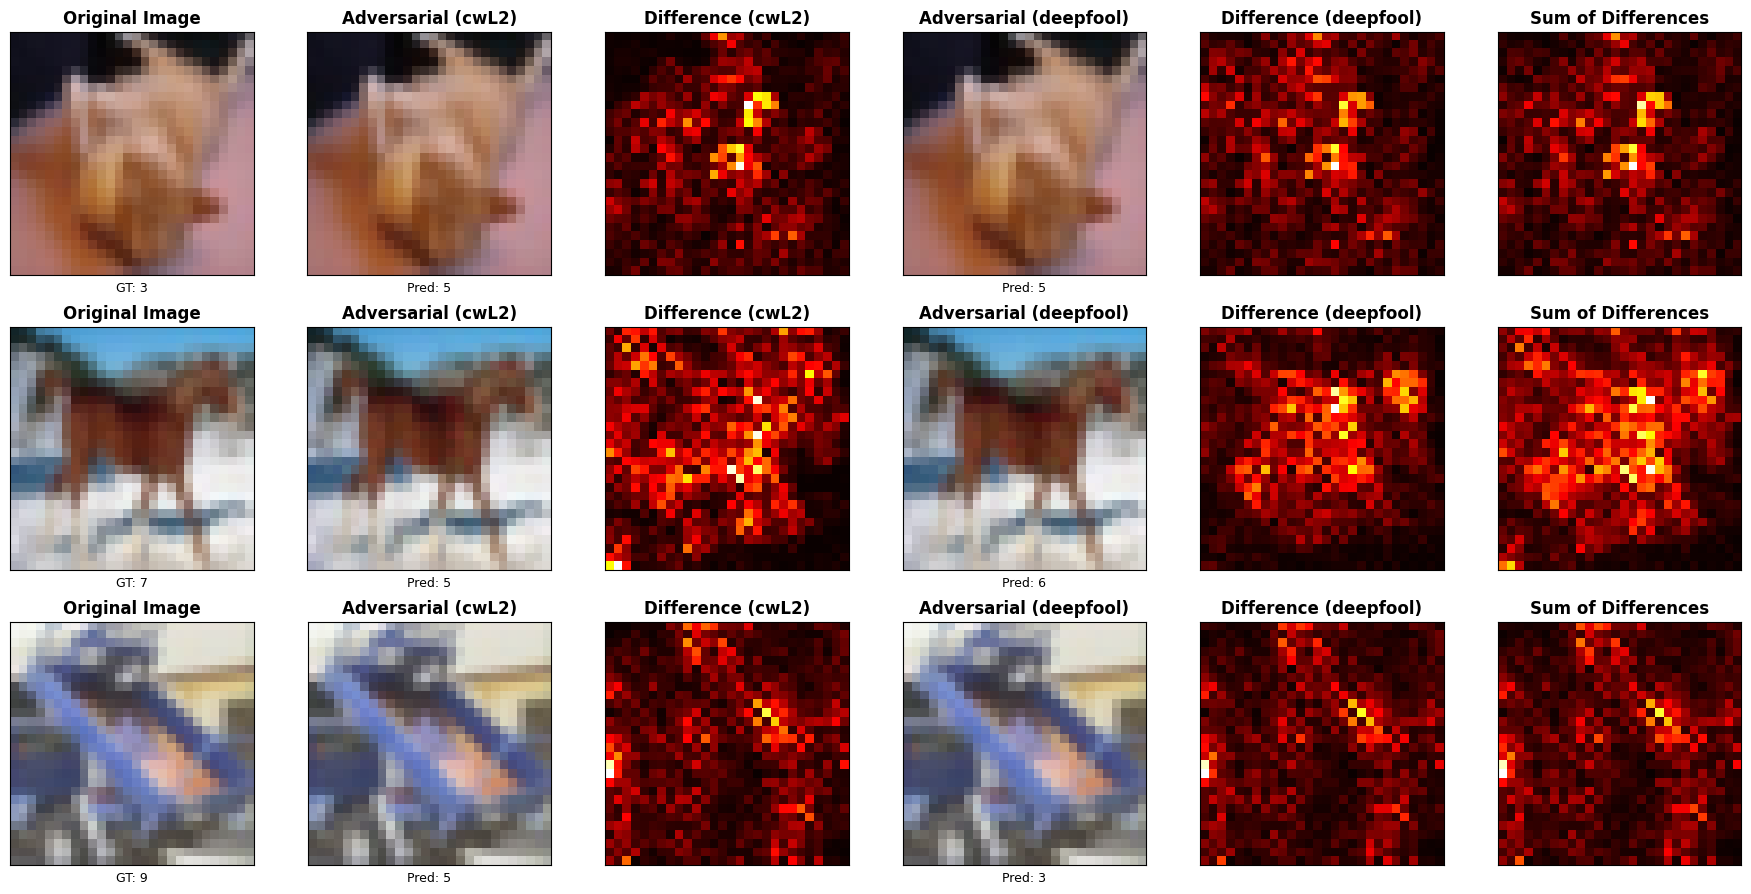

In [30]:
# Create explainer with GMD differences
explainer_gmd = AdversarialExplainer(
    classifier,
    methods,
    difference_calculation='GMD',
    cmap=cmap
)

# Generate and visualize adversarial examples
explainer_gmd.explain(input_imgs, labels.numpy(), predict_labels=True)